Step 1. 필수 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from tqdm.auto import tqdm
import os

In [2]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
# 수정된 경로
from langchain_chroma import Chroma
from langchain_core.documents import Document
# OpenAI API Key 설정
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [3]:
# 데이터 로드 (전처리 완료된 파일)
df = pd.read_csv('./final_reviewdata.csv')
# 정답 레이블 수치화 (추천: 1, 비추천: 0)
df['label'] = df['추천여부'].map({'추천': 1, '비추천': 0})
print(f"전체 데이터 구성: \n{df['추천여부'].value_counts()}")

전체 데이터 구성: 
추천여부
추천     16916
비추천     7071
Name: count, dtype: int64


Step 2. AI 감성 분석 예측 함수 (검증용)
전체 데이터를 LLM으로 돌리면 비용이 많이 발생하므로, 
**검증용 샘플(예: 100~200건)**을 무작위 추출하여 테스트하는 방식을 추천합니다.

In [4]:
# 검증용 샘플 데이터 추출 (불균형 고려하여 추천/비추천 고르게 추출)
test_df = pd.concat([
    df[df['label'] == 1].sample(50),
    df[df['label'] == 0].sample(50)
]).sample(frac=1).reset_index(drop=True)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [5]:
def predict_sentiment(text):
    prompt = ChatPromptTemplate.from_template("""
    아래 게임 리뷰의 감성을 판단해서 '추천' 또는 '비추천' 중 하나로만 대답해줘.
    리뷰: {review}
    답변:
    """)
    chain = prompt | llm
    response = chain.invoke({"review": text[:500]}) # 속도를 위해 500자 제한
    return 1 if "추천" in response.content and "비추천" not in response.content else 0

In [6]:
# 예측 실행
tqdm.pandas()
test_df['prediction'] = test_df['cleaned_review'].progress_apply(predict_sentiment)

  0%|          | 0/100 [00:00<?, ?it/s]

Step 3. 메트릭 측정 (Accuracy, F1-Score)

In [7]:
y_true = test_df['label']
y_pred = test_df['prediction']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"--- 모델 검증 결과 ---")
print(f"정확도 (Accuracy): {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\n[상세 리포트]")
print(classification_report(y_true, y_pred, target_names=['비추천(Neg)', '추천(Pos)']))

--- 모델 검증 결과 ---
정확도 (Accuracy): 0.7900
F1-Score: 0.7529

[상세 리포트]
              precision    recall  f1-score   support

    비추천(Neg)       0.72      0.94      0.82        50
     추천(Pos)       0.91      0.64      0.75        50

    accuracy                           0.79       100
   macro avg       0.82      0.79      0.79       100
weighted avg       0.82      0.79      0.79       100



Step 4. 혼동 행렬 시각화 (Confusion Matrix)

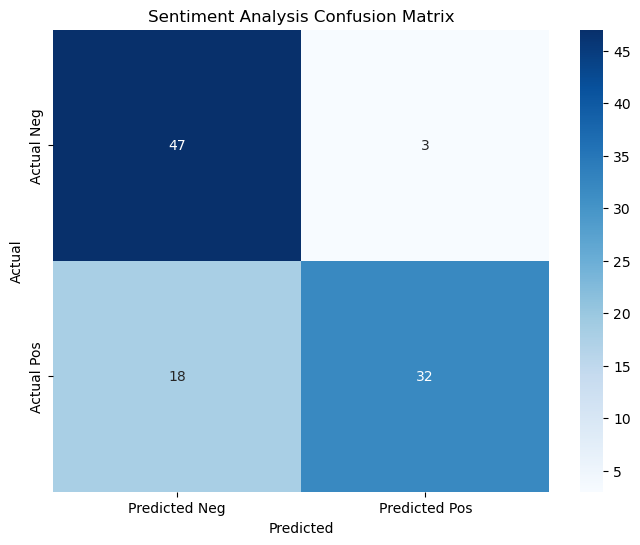


--- 주요 오답 사례 분석 ---
리뷰: 재밌음 근데 뉴비 입문하기는 힘듬...
실제: 추천, AI 예측: 비추천
------------------------------
리뷰: 전작에서 기대했던 재미도 충분히 주고 로 부족했던 부분도 채워주는데 난이도가 너무 급상승해서 완벽한 덱을 구성하지 못하면 챕터에서는 한 순간에 골로 가버려서 너무 높은 난이도가 되...
실제: 추천, AI 예측: 비추천
------------------------------
리뷰: 어떻게 씨발 이게임은 씨발 해도 씨발 실력이 씨발 안늘까요...
실제: 추천, AI 예측: 비추천
------------------------------
리뷰: 추억일 때가 좋다...
실제: 추천, AI 예측: 비추천
------------------------------
리뷰: 게임이 늙다못해 송장이 되버렸다 송장에 화장을 떡칠 하고있는데 이것을 게임이라고 부를수 있을지 그렇다 이것은 시대를 거스르는 디지털 아트 같은것이다...
실제: 추천, AI 예측: 비추천
------------------------------


In [8]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 오답 분석 (상위 5개)
error_cases = test_df[test_df['label'] != test_df['prediction']].head(5)
print("\n--- 주요 오답 사례 분석 ---")
for i, row in error_cases.iterrows():
    print(f"리뷰: {row['cleaned_review'][:100]}...")
    print(f"실제: {row['추천여부']}, AI 예측: {'추천' if row['prediction']==1 else '비추천'}")
    print("-" * 30)

Step 5. 추천 시스템 검증 데이터셋 준비

In [9]:
# 검증용 테스트 셋 (상황에 맞춰 확장 가능)
test_queries = [
    {
        "query": "친구들과 함께 즐기기 좋은 무료 멀티플레이어 게임 추천해줘",
        "expected_games": ["PUBG: BATTLEGROUNDS", "Overwatch 2", "Apex Legends"]
    },
    {
        "query": "타격감이 뛰어나고 난이도가 높은 소울라이크 액션 게임",
        "expected_games": ["Elden Ring", "Dark Souls III", "Lies of P", "Sekirol"]
    },
    {
        "query": "스토리가 감동적이고 힐링되는 인디 게임",
        "expected_games": ["Stardew Valley", "Undertale", "Spiritfarer"]
    }
]

print(f"테스트 쿼리 개수: {len(test_queries)}")

테스트 쿼리 개수: 3


In [11]:
# --- [Raw Data 검증 추가] ---
# 에러가 발생하는 줄을 건너뛰도록(skip) 설정하고, 데이터 타입을 유연하게 처리합니다.
raw_df = pd.read_csv('../reviewdata/popgame.csv', on_bad_lines='skip', low_memory=False) 

# 만약 데이터 유실을 최소화하고 싶다면 아래처럼 'quoting' 옵션을 추가해볼 수도 있습니다.
# raw_df = pd.read_csv('../reviewdata/popgame.csv', quoting=3, on_bad_lines='warn')

raw_df['label'] = raw_df['추천여부'].map({'추천': 1, '비추천': 0})

# 1. Raw Data에서 50건 샘플링
raw_test_samples = pd.concat([
    raw_df[raw_df['label'] == 1].sample(25),
    raw_df[raw_df['label'] == 0].sample(25)
]).sample(frac=1).reset_index(drop=True)

# 2. 전처리 없는 '리뷰 원문' 그대로 AI에게 질문
print("Raw Data 감성 분석 진행 중...")
raw_test_samples['prediction'] = raw_test_samples['리뷰 원문'].progress_apply(predict_sentiment)

# 3. 정확도 계산 및 출력
raw_accuracy = accuracy_score(raw_test_samples['label'], raw_test_samples['prediction'])
print(f"\n[Raw Data vs Preprocessed 비교]")
print(f"전처리 전(Raw) 정확도: {raw_accuracy:.4f}")
print(f"전처리 후(Cleaned) 정확도: {accuracy:.4f} (이전 수치)")

# 상세 리포트
print("\n[Raw Data 상세 리포트]")
print(classification_report(raw_test_samples['label'], raw_test_samples['prediction']))

Raw Data 감성 분석 진행 중...


  0%|          | 0/50 [00:00<?, ?it/s]


[Raw Data vs Preprocessed 비교]
전처리 전(Raw) 정확도: 0.8600
전처리 후(Cleaned) 정확도: 0.7900 (이전 수치)

[Raw Data 상세 리포트]
              precision    recall  f1-score   support

           0       0.82      0.92      0.87        25
           1       0.91      0.80      0.85        25

    accuracy                           0.86        50
   macro avg       0.87      0.86      0.86        50
weighted avg       0.87      0.86      0.86        50

